# ETAPE 6 — Analyse Métier : Caractérisation des boutiques SUD-EST
**Projet : Optimisation du Réseau de Boutiques TELECOM — Groupe 5 SUD-EST**

---
### Objectifs
- Construire un **tableau de bord par boutique** avec toutes les métriques clés
- Identifier les **patterns** : boutiques locales vs régionales, spécialisées vs généralistes
- Préparer les données pour le modèle business (Etape 7)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130})
sns.set_theme(style='whitegrid')

# Charger le dataset enrichi (Etape 5)
try:
    df = pd.read_csv('base_enrichie_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
    print("Dataset enrichi chargé.")
except FileNotFoundError:
    df = pd.read_csv('base_travail_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
    print("Dataset de base chargé (enrichi non trouvé).")

print(f"{len(df):,} lignes x {df.shape[1]} colonnes")

Dataset enrichi chargé.
226,677 lignes x 34 colonnes


## 6.1 Tableau de bord par boutique

In [2]:
ARPU = {'T': 200, 'B': 350, 'F': 350}
ARPU_DEFAULT = 200
COUT_CC = 85_000
COUT_CV = 65_000

# Calcul de la marge estimée si non présente
if 'ca_ligne' not in df.columns:
    df['ca_ligne'] = df['LINE_TYPE'].map(ARPU).fillna(ARPU_DEFAULT)

# Geolife mode
def mode_val(s):
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

# Reconstruire age_client si absent
if 'age_client' not in df.columns:
    def parse_decade(val):
        try: return int(str(val).split('-')[0])
        except: return np.nan
    df['birth_decade'] = df['PERSON_BIRTH_DT_year'].apply(parse_decade)
    df['age_client'] = 2024 - (df['birth_decade'] + 5)

# Tableau de bord agrégé par boutique
tdb = df.groupby('ORDER_SHOP_CD').agg(
    volume_total=('LINE_TYPE', 'count'),
    ca_estime=('ca_ligne', 'sum'),
    age_moyen=('age_client', 'mean'),
    distance_moyenne=('distance_km', 'mean'),
    geolife_dominant=('GEOLIFE_AGG', mode_val),
    emplacement=('Emplacement_PDV', 'first'),
    surface=('Surface_COMMERC', 'first'),
    canal=('MKT_CHANNL_LB', 'first'),
).reset_index()

# Mix produit
for lt in df['LINE_TYPE'].unique():
    tdb[f'vol_{lt}'] = df[df['LINE_TYPE'] == lt].groupby('ORDER_SHOP_CD').size().reindex(tdb['ORDER_SHOP_CD']).values

vol_cols = [c for c in tdb.columns if c.startswith('vol_')]
for c in vol_cols:
    tdb[c] = tdb[c].fillna(0).astype(int)
    tdb[f'pct_{c[4:]}'] = (tdb[c] / tdb['volume_total'] * 100).round(1)

# Coût et marge
tdb['cout_fonctionnement'] = tdb['emplacement'].map({'CC': COUT_CC, 'CV': COUT_CV}).fillna(COUT_CV)
tdb['marge_estimee'] = tdb['ca_estime'] - tdb['cout_fonctionnement']
tdb['score_rentabilite'] = (tdb['ca_estime'] / tdb['cout_fonctionnement']).round(2)
tdb['rentable'] = tdb['marge_estimee'] > 0

# Croissance yoy si disponible
years = sorted(df['PERIOD_YYYY'].unique())
if len(years) >= 2:
    yr_n1, yr_n = years[-2], years[-1]
    vol_pivot = df.groupby(['ORDER_SHOP_CD', 'PERIOD_YYYY']).size().unstack(fill_value=0)
    if yr_n1 in vol_pivot.columns and yr_n in vol_pivot.columns:
        vol_pivot['croissance_yoy'] = (
            (vol_pivot[yr_n] - vol_pivot[yr_n1]) / vol_pivot[yr_n1].replace(0, np.nan) * 100
        ).round(1)
        tdb = tdb.merge(vol_pivot[['croissance_yoy']].reset_index(), on='ORDER_SHOP_CD', how='left')

# Benchmark interne (médiane SUD-EST)
median_vol = tdb['volume_total'].median()
tdb['vs_mediane'] = ((tdb['volume_total'] - median_vol) / median_vol * 100).round(1)

print(f"Tableau de bord : {len(tdb)} boutiques")
tdb[['ORDER_SHOP_CD', 'volume_total', 'ca_estime', 'marge_estimee',
     'score_rentabilite', 'emplacement', 'surface', 'age_moyen']].head(10)

Tableau de bord : 1068 boutiques


,ORDER_SHOP_CD,volume_total,ca_estime,marge_estimee,score_rentabilite,emplacement,surface,age_moyen
0,01011FG1-6,14,2800.0,-62200.0,0.04,CV,100.0,58.285714
1,01100FG1-7,11,2200.0,-62800.0,0.03,CV,207.0,55.363636
2,01210FV3-1,39,7800.0,-57200.0,0.12,CV,142.0,54.142857
3,01500FG1-5,8,1600.0,-63400.0,0.02,CV,108.0,51.500000
4,01APVEBOUR,1,200.0,-64800.0,0.00,NaN,NaN,89.000000
5,01APVEOYON,1,200.0,-64800.0,0.00,NaN,NaN,19.000000
6,01GTPROTHO,1,200.0,-64800.0,0.00,NaN,NaN,NaN
7,01PHSETHOI,23,4600.0,-80400.0,0.05,CC,75.0,38.000000
8,02000FL3-6,7,1400.0,-83600.0,0.02,CC,110.0,21.000000
9,02208FT9-5,4,800.0,-64200.0,0.01,CV,154.0,36.500000


## 6.2 Distribution des métriques clés

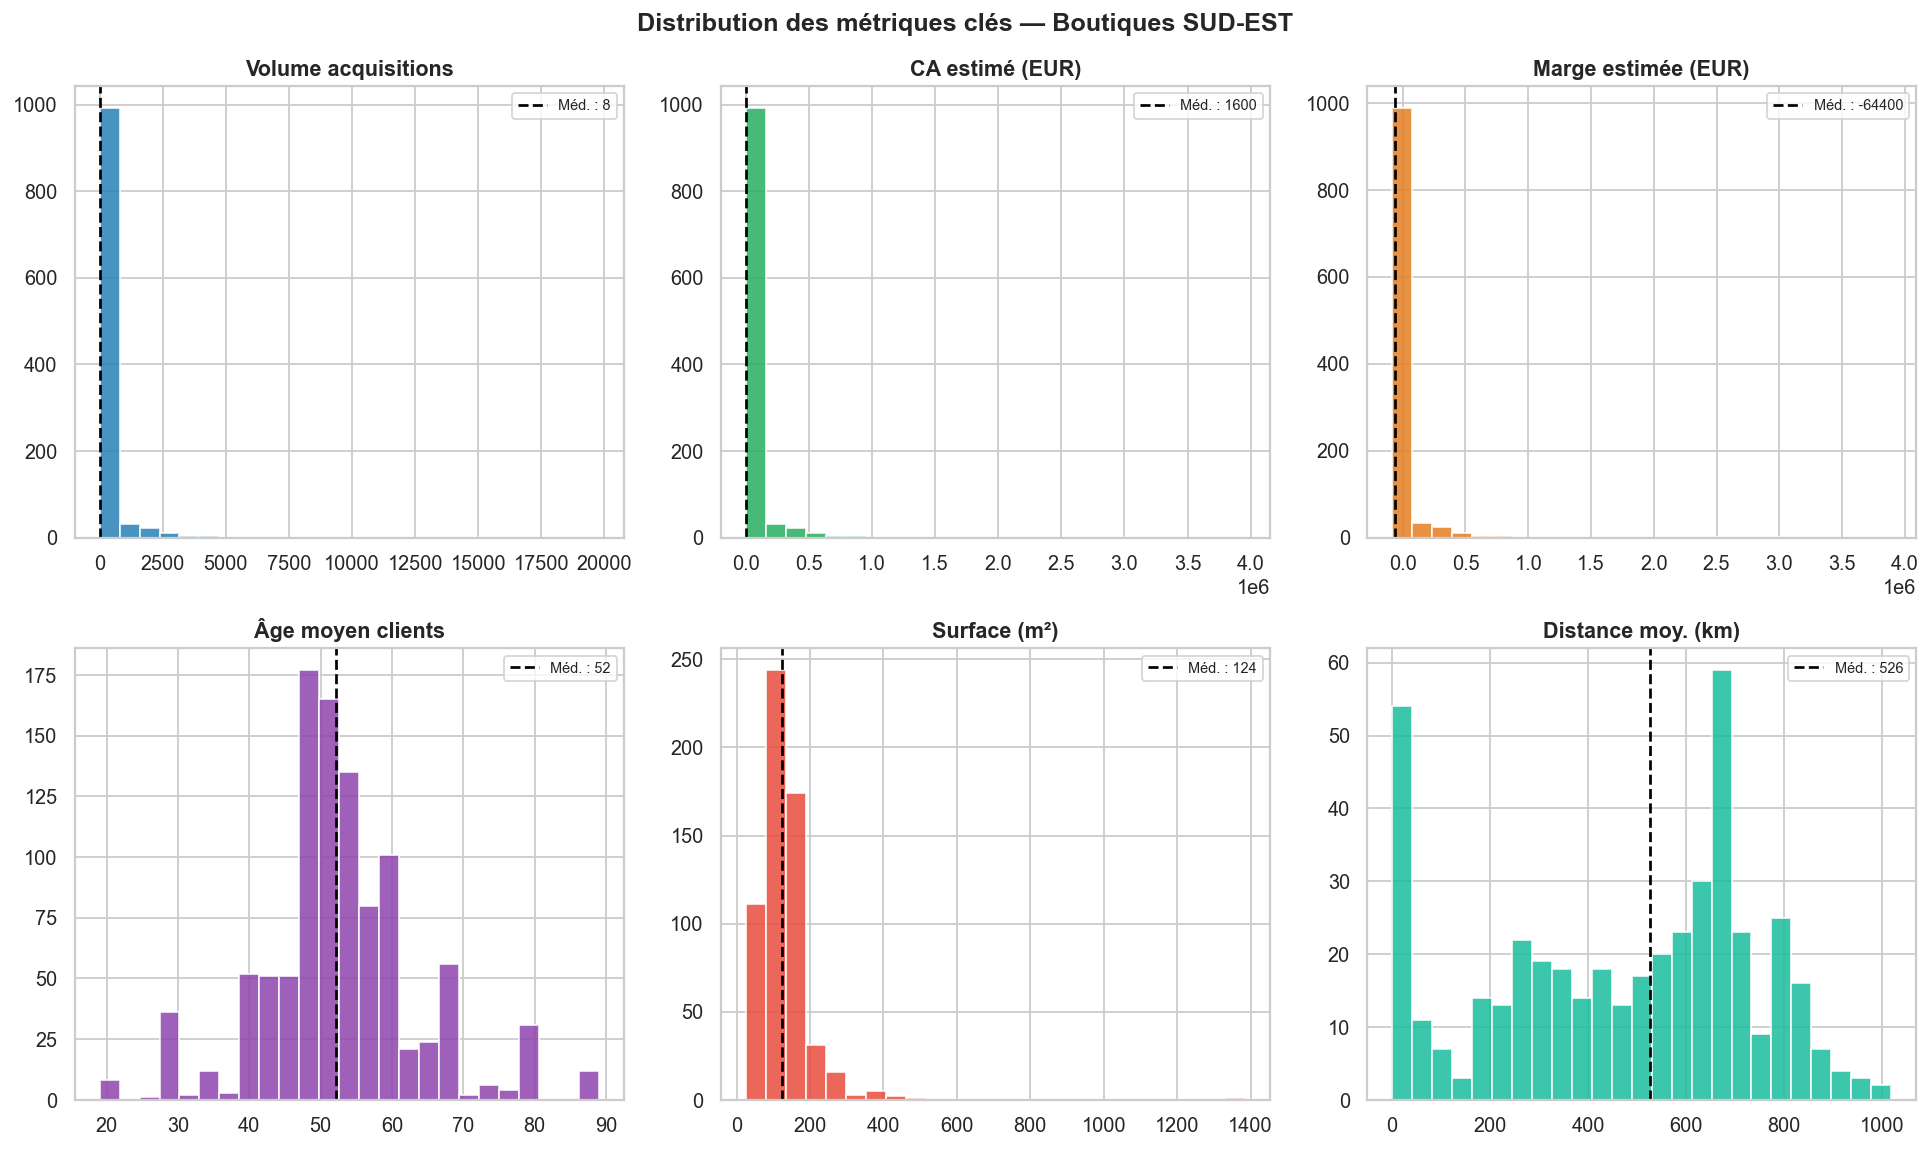

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

metrics = [
    ('volume_total',        'Volume acquisitions',   '#2980b9'),
    ('ca_estime',           'CA estimé (EUR)',        '#27ae60'),
    ('marge_estimee',       'Marge estimée (EUR)',    '#e67e22'),
    ('age_moyen',           'Âge moyen clients',     '#8e44ad'),
    ('surface',             'Surface (m²)',           '#e74c3c'),
    ('distance_moyenne',    'Distance moy. (km)',     '#1abc9c'),
]

for ax, (col, label, color) in zip(axes, metrics):
    data = tdb[col].dropna()
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Méd. : {data.median():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des métriques clés — Boutiques SUD-EST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('6_metriques_distribution.png', bbox_inches='tight')
plt.show()

## 6.3 Analyse CC vs CV — Performance comparée


=== BENCHMARK CC vs CV ===
emplacement          CC       CV  HORS CV ET CC
nb_boutiques      292.0    295.0            1.0
vol_median          9.5      8.0            2.0
ca_median        1900.0   1600.0          400.0
marge_median   -83100.0 -63400.0       -64600.0
score_median        0.0      0.0            0.0
age_median         52.2     53.3           64.0
surface_median    129.0    118.0           97.0
pct_rentables      10.0     10.0            0.0


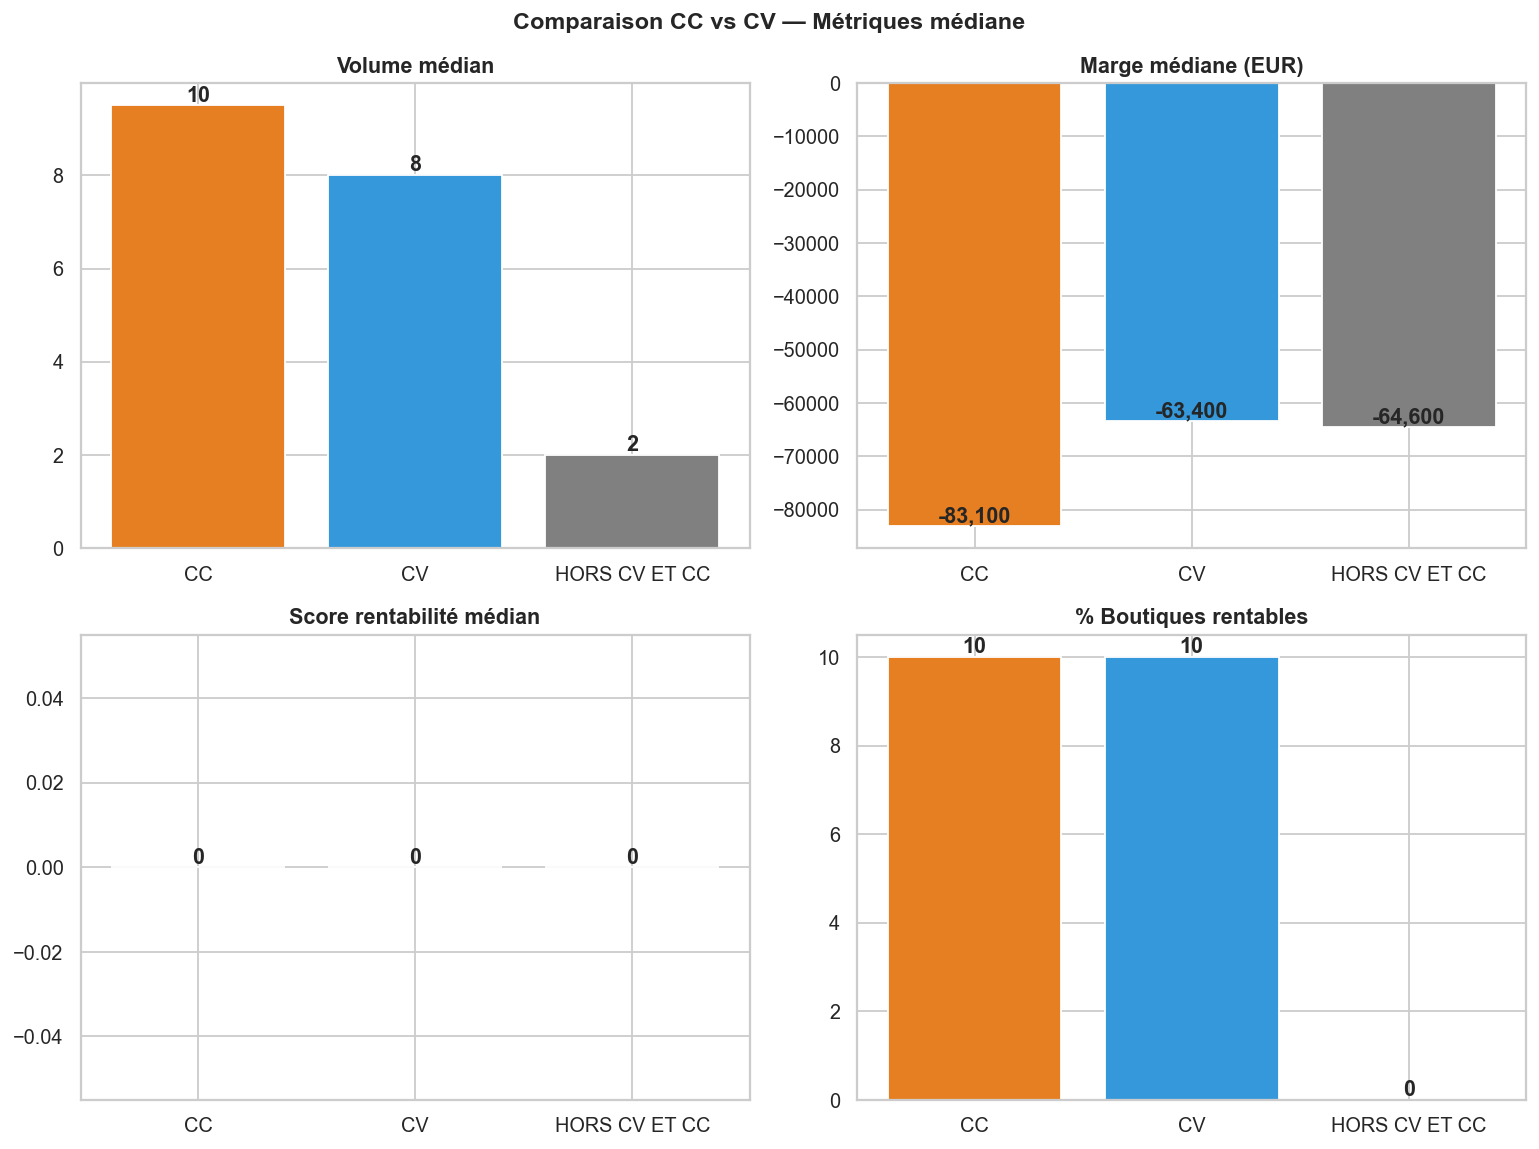

In [4]:
emp_stats = tdb.groupby('emplacement').agg(
    nb_boutiques=('ORDER_SHOP_CD', 'count'),
    vol_median=('volume_total', 'median'),
    ca_median=('ca_estime', 'median'),
    marge_median=('marge_estimee', 'median'),
    score_median=('score_rentabilite', 'median'),
    age_median=('age_moyen', 'median'),
    surface_median=('surface', 'median'),
    pct_rentables=('rentable', 'mean')
).round(1)
emp_stats['pct_rentables'] = (emp_stats['pct_rentables'] * 100).round(1)

print("\n=== BENCHMARK CC vs CV ===")
print(emp_stats.T.to_string())

# Graphiques comparatifs
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
cols = [('vol_median', 'Volume médian'), ('marge_median', 'Marge médiane (EUR)'),
        ('score_median', 'Score rentabilité médian'), ('pct_rentables', '% Boutiques rentables')]
colors_emp = {'CC': '#e67e22', 'CV': '#3498db'}

for ax, (col, label) in zip(axes.flatten(), cols):
    vals = emp_stats[col].dropna()
    bars = ax.bar(vals.index, vals.values, color=[colors_emp.get(e, 'gray') for e in vals.index])
    ax.set_title(label, fontweight='bold')
    for b in bars:
        ax.annotate(f'{b.get_height():,.0f}', (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontweight='bold')

plt.suptitle('Comparaison CC vs CV — Métriques médiane', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('6_cc_vs_cv.png', bbox_inches='tight')
plt.show()

## 6.4 Segmentation des boutiques par profil

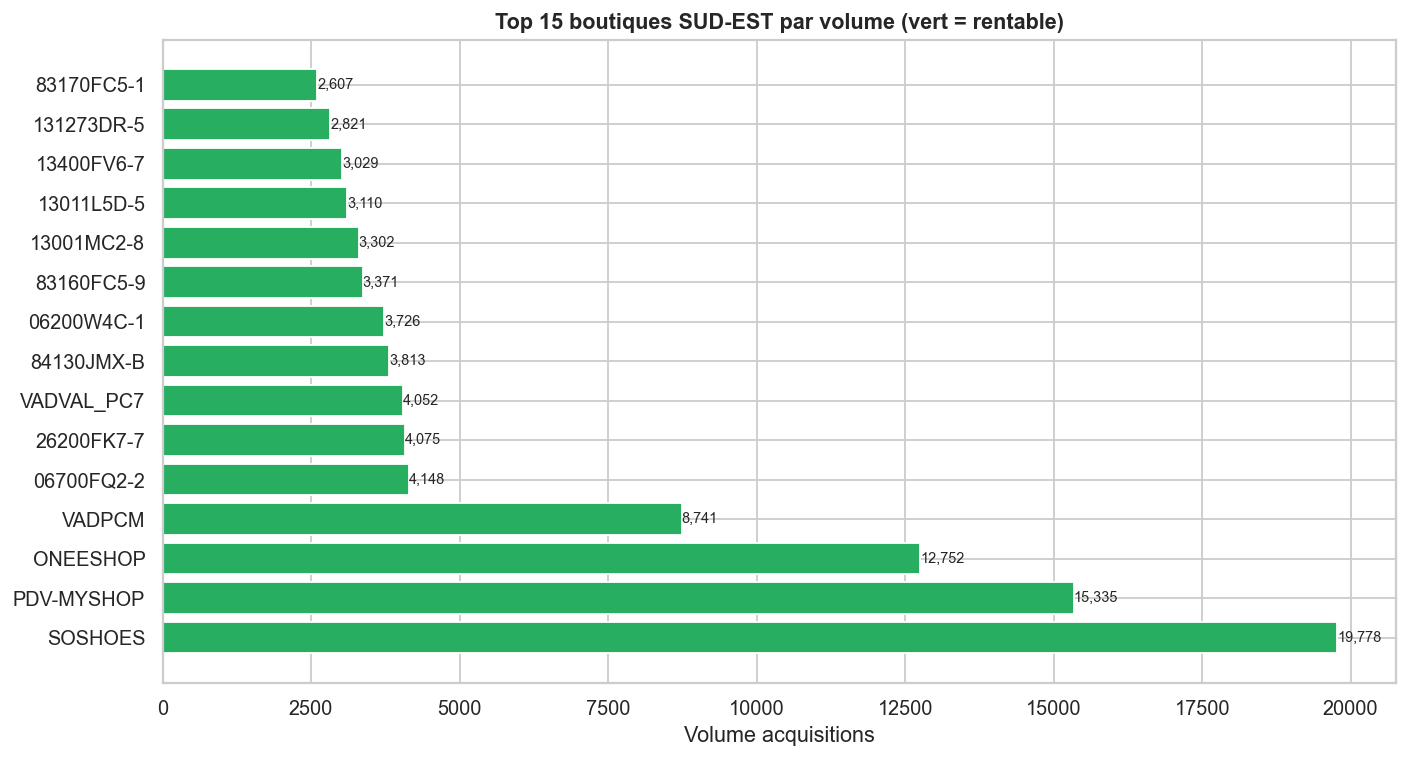


Top 15 boutiques :
ORDER_SHOP_CD  volume_total emplacement  marge_estimee  score_rentabilite     profil_chalandise         geolife_dominant
      SOSHOES         19778         NaN      3890600.0              60.86               Inconnu    Urbain classe moyenne
   PDV-MYSHOP         15335         NaN      3002000.0              47.18               Inconnu    Urbain classe moyenne
     ONEESHOP         12752         NaN      2485400.0              39.24               Inconnu    Urbain classe moyenne
       VADPCM          8741         NaN      1683200.0              26.90               Inconnu     Résidence secondaire
   06700FQ2-2          4148          CC       744600.0               9.76 Semi-locale (10-20km)    Urbain classe moyenne
   26200FK7-7          4075          CV       750000.0              12.54     Régionale (>20km) PériUrbain en croissance
   VADVAL_PC7          4052         NaN       745400.0              12.47               Inconnu     Résidence secondaire
   84130JMX-

In [5]:
# Classer les boutiques : locale (<10km) vs régionale (>20km)
def profil_chalandise(dist):
    if pd.isna(dist): return 'Inconnu'
    if dist < 10: return 'Locale (<10km)'
    if dist < 20: return 'Semi-locale (10-20km)'
    return 'Régionale (>20km)'

tdb['profil_chalandise'] = tdb['distance_moyenne'].apply(profil_chalandise)

# Classement boutiques par volume
top15 = tdb.nlargest(15, 'volume_total')[[
    'ORDER_SHOP_CD', 'volume_total', 'emplacement', 'marge_estimee',
    'score_rentabilite', 'profil_chalandise', 'geolife_dominant'
]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#27ae60' if r else '#e74c3c' for r in tdb.nlargest(15, 'volume_total')['rentable']]
bars = ax.barh(top15['ORDER_SHOP_CD'], top15['volume_total'], color=colors)
ax.set_title('Top 15 boutiques SUD-EST par volume (vert = rentable)', fontweight='bold')
ax.set_xlabel('Volume acquisitions')
for b in bars:
    ax.annotate(f'{int(b.get_width()):,}', (b.get_width(), b.get_y() + b.get_height()/2),
                va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.savefig('6_top15_boutiques.png', bbox_inches='tight')
plt.show()

print("\nTop 15 boutiques :")
print(top15.to_string(index=False))

## 6.5 Heatmap : boutique × type produit

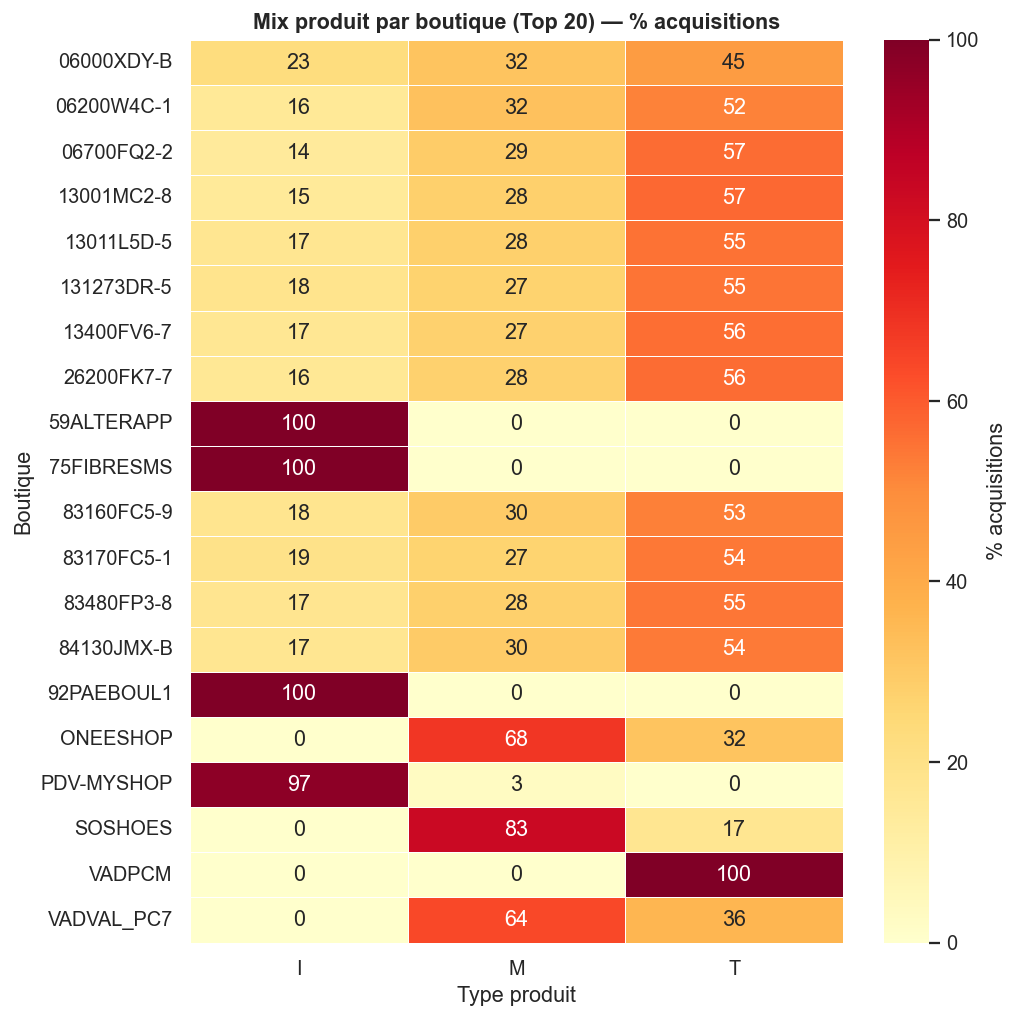

In [6]:
# Top 20 boutiques en volume
top20_shops = tdb.nlargest(20, 'volume_total')['ORDER_SHOP_CD'].tolist()
lt_heat = df[df['ORDER_SHOP_CD'].isin(top20_shops)].groupby(['ORDER_SHOP_CD', 'LINE_TYPE']).size().unstack(fill_value=0)

# Normaliser en % par boutique
lt_heat_pct = lt_heat.div(lt_heat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(max(8, len(lt_heat.columns)*1.5), 8))
sns.heatmap(lt_heat_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% acquisitions'})
ax.set_title('Mix produit par boutique (Top 20) — % acquisitions', fontweight='bold')
ax.set_xlabel('Type produit')
ax.set_ylabel('Boutique')
plt.tight_layout()
plt.savefig('6_heatmap_boutiques.png', bbox_inches='tight')
plt.show()

## 6.6 Analyse saisonnière

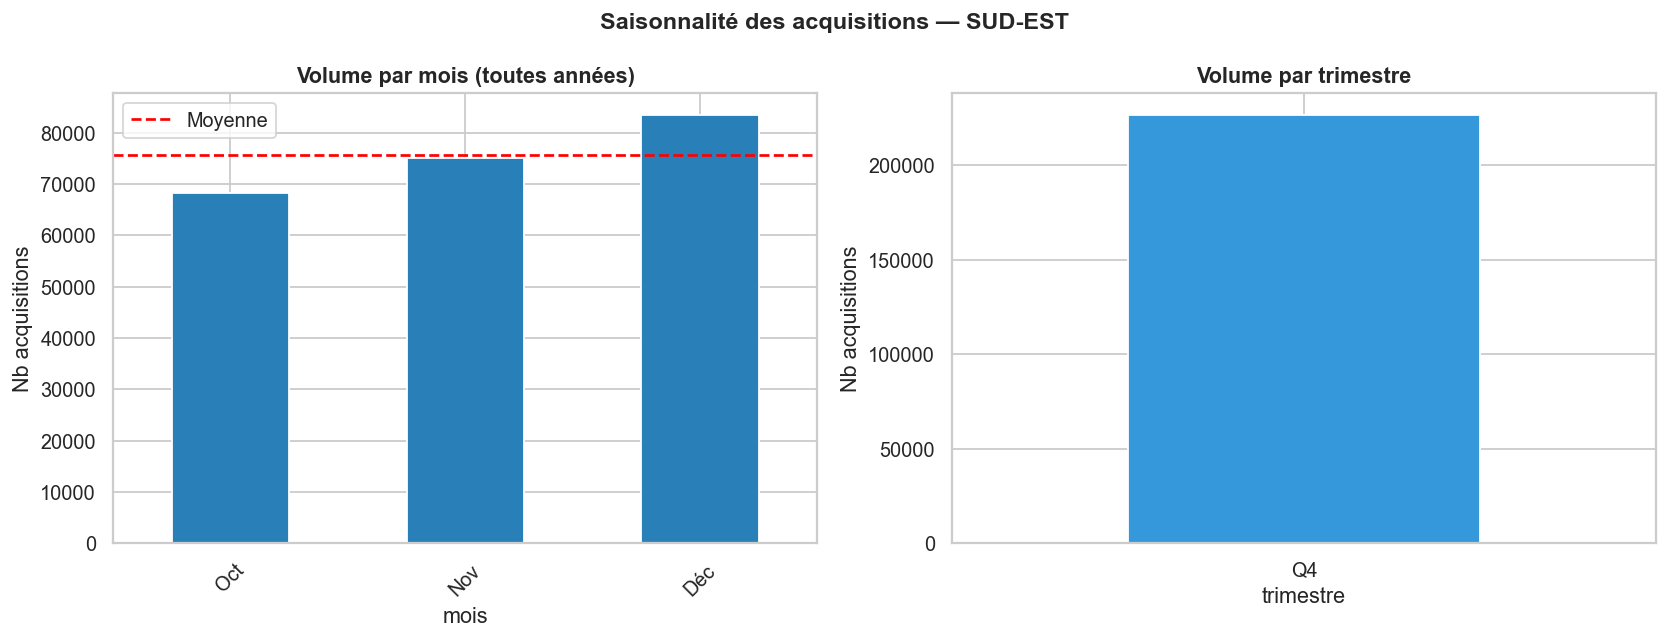

In [7]:
df['trimestre'] = df['PERIOD_MM'].apply(lambda m: f'Q{(m-1)//3+1}')
df['mois'] = df['PERIOD_MM']

# Volume par mois (toutes années confondues)
mois_vol = df.groupby('mois').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
mois_vol.plot(kind='bar', ax=axes[0], color='#2980b9')
axes[0].set_xticklabels([mois_labels[i-1] for i in mois_vol.index], rotation=45)
axes[0].set_title('Volume par mois (toutes années)', fontweight='bold')
axes[0].set_ylabel('Nb acquisitions')
axes[0].axhline(mois_vol.mean(), color='red', linestyle='--', label='Moyenne')
axes[0].legend()

# Volume par trimestre
trim_vol = df.groupby('trimestre').size()
trim_vol.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#f39c12', '#27ae60'])
axes[1].set_title('Volume par trimestre', fontweight='bold')
axes[1].set_ylabel('Nb acquisitions')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Saisonnalité des acquisitions — SUD-EST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('6_saisonnalite.png', bbox_inches='tight')
plt.show()

## 6.7 Sauvegarde du tableau de bord boutique

In [8]:
tdb.to_csv('tableau_bord_boutiques.csv', index=False)
print(f"tableau_bord_boutiques.csv sauvegardé : {len(tdb)} boutiques")

# Résumé final
print("\n=== RÉSUMÉ ANALYSE MÉTIER ===")
print(f"Nb boutiques analysées         : {len(tdb)}")
print(f"Volume médian par boutique     : {tdb['volume_total'].median():.0f} acquisitions")
print(f"CA médian par boutique         : {tdb['ca_estime'].median():,.0f} EUR")
print(f"Marge médiane par boutique     : {tdb['marge_estimee'].median():,.0f} EUR")
print(f"% Boutiques rentables          : {tdb['rentable'].mean()*100:.1f}%")
if 'croissance_yoy' in tdb.columns:
    print(f"Croissance YoY médiane         : {tdb['croissance_yoy'].median():.1f}%")

tableau_bord_boutiques.csv sauvegardé : 1068 boutiques

=== RÉSUMÉ ANALYSE MÉTIER ===
Nb boutiques analysées         : 1068
Volume médian par boutique     : 8 acquisitions
CA médian par boutique         : 1,600 EUR
Marge médiane par boutique     : -64,400 EUR
% Boutiques rentables          : 9.6%
Croissance YoY médiane         : 0.0%


## Conclusion Etape 6

Le tableau de bord par boutique est construit avec toutes les métriques nécessaires.

**→ Prochaine étape : Modèle Business & Recommandations (Etape 7)**